<a href="https://colab.research.google.com/github/Zforeror/Tareas-Matem-ticas-de-aprendizaje-de-m-quina/blob/main/Ejercicios_Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ejercicio 2.3**

Regresión directa:
y = -0.166667 + (1.500000)x

Modelo generativo:
x = 0.142857 + (0.642857)y

Modelo generativo después de invertirlo:
y = -0.222222 + (1.555556)x

Comparación de predicciones:
x = 0.0, y real = 0.0, directa = -0.166667, generativa invertida = -0.222222
x = 1.0, y real = 1.0, directa = 1.333333, generativa invertida = 1.333333
x = 2.0, y real = 3.0, directa = 2.833333, generativa invertida = 2.888889


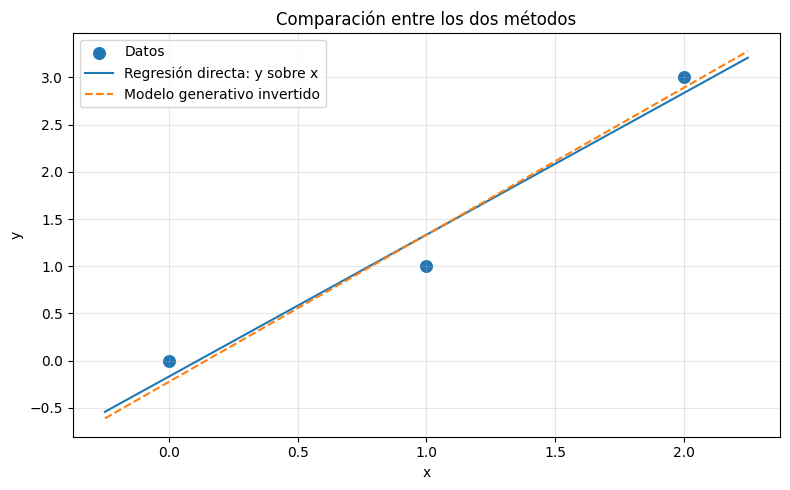

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def ajustar_regresion_directa(x: np.ndarray,
                              y: np.ndarray) -> tuple[float, float]:
    """
    Ajusta el modelo y = phi_0 + phi_1*x mediante mínimos cuadrados.
    Retorna el intercepto phi_0 y la pendiente phi_1.
    """
    x_media = np.mean(x)
    y_media = np.mean(y)

    denominador = np.sum((x - x_media) ** 2)

    if np.isclose(denominador, 0.0):
        raise ValueError(
            "No se puede ajustar la regresión porque todos los valores de x "
            "son iguales."
        )

    phi_1 = np.sum((x - x_media) * (y - y_media)) / denominador
    phi_0 = y_media - phi_1 * x_media

    return phi_0, phi_1


def ajustar_modelo_generativo(x: np.ndarray,
                              y: np.ndarray) -> tuple[float, float]:
    """
    Ajusta el modelo generativo x = phi_0 + phi_1*y.
    Retorna el intercepto phi_0 y la pendiente phi_1.
    """
    x_media = np.mean(x)
    y_media = np.mean(y)

    denominador = np.sum((y - y_media) ** 2)

    if np.isclose(denominador, 0.0):
        raise ValueError(
            "No se puede ajustar el modelo generativo porque todos los "
            "valores de y son iguales."
        )

    phi_1 = np.sum((y - y_media) * (x - x_media)) / denominador
    phi_0 = x_media - phi_1 * y_media

    return phi_0, phi_1


# Datos de ejemplo
x = np.array([0.0, 1.0, 2.0])
y = np.array([0.0, 1.0, 3.0])

# ---------------------------------------------------------
# Método 1: regresión discriminativa y = phi_0 + phi_1*x
# ---------------------------------------------------------
phi_0_directo, phi_1_directo = ajustar_regresion_directa(x, y)

# ---------------------------------------------------------
# Método 2: modelo generativo x = phi_0 + phi_1*y
# ---------------------------------------------------------
phi_0_generativo, phi_1_generativo = ajustar_modelo_generativo(x, y)

if np.isclose(phi_1_generativo, 0.0):
    raise ValueError(
        "El modelo generativo no se puede invertir porque su pendiente es cero."
    )

# Invertimos x = phi_0 + phi_1*y para obtener
# y = -phi_0/phi_1 + (1/phi_1)*x
intercepto_inverso = -phi_0_generativo / phi_1_generativo
pendiente_inversa = 1.0 / phi_1_generativo

print("Regresión directa:")
print(
    f"y = {phi_0_directo:.6f} "
    f"+ ({phi_1_directo:.6f})x"
)

print("\nModelo generativo:")
print(
    f"x = {phi_0_generativo:.6f} "
    f"+ ({phi_1_generativo:.6f})y"
)

print("\nModelo generativo después de invertirlo:")
print(
    f"y = {intercepto_inverso:.6f} "
    f"+ ({pendiente_inversa:.6f})x"
)

# Predicciones sobre los datos originales
prediccion_directa = phi_0_directo + phi_1_directo * x
prediccion_generativa = intercepto_inverso + pendiente_inversa * x

print("\nComparación de predicciones:")

for x_i, y_i, y_directa, y_generativa in zip(
    x,
    y,
    prediccion_directa,
    prediccion_generativa
):
    print(
        f"x = {x_i:.1f}, "
        f"y real = {y_i:.1f}, "
        f"directa = {y_directa:.6f}, "
        f"generativa invertida = {y_generativa:.6f}"
    )

# Gráfica de ambas rectas
x_grafica = np.linspace(
    np.min(x) - 0.25,
    np.max(x) + 0.25,
    200
)

y_directa_grafica = (
    phi_0_directo + phi_1_directo * x_grafica
)

y_generativa_grafica = (
    intercepto_inverso + pendiente_inversa * x_grafica
)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=70, label="Datos")
plt.plot(
    x_grafica,
    y_directa_grafica,
    label="Regresión directa: y sobre x"
)
plt.plot(
    x_grafica,
    y_generativa_grafica,
    linestyle="--",
    label="Modelo generativo invertido"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparación entre los dos métodos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Capitulo 3
**Ejercicio 3.8**

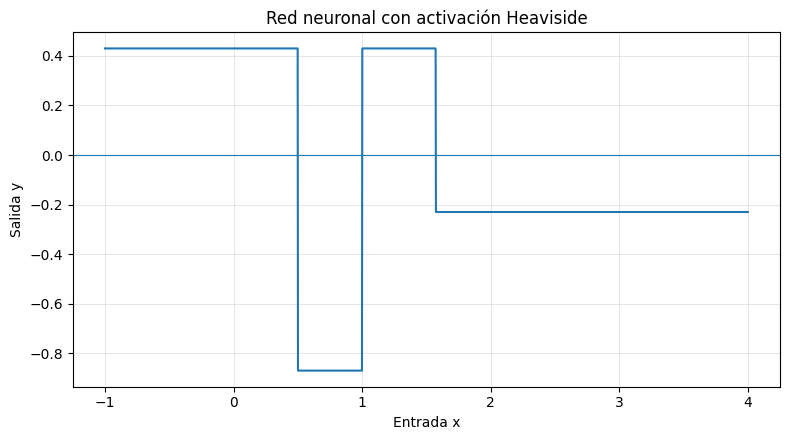

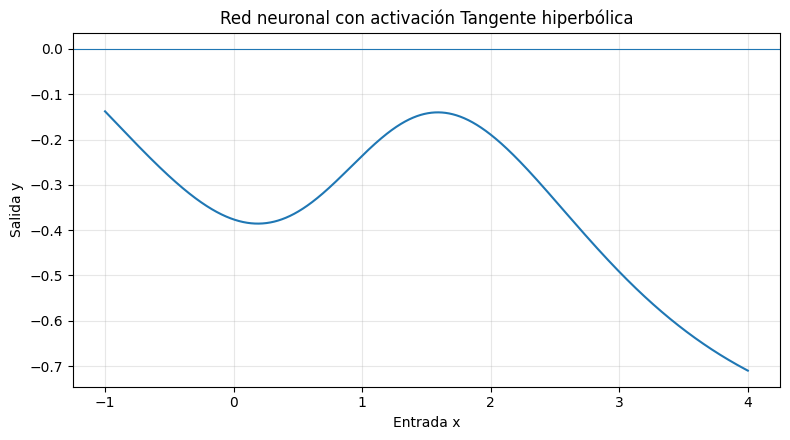

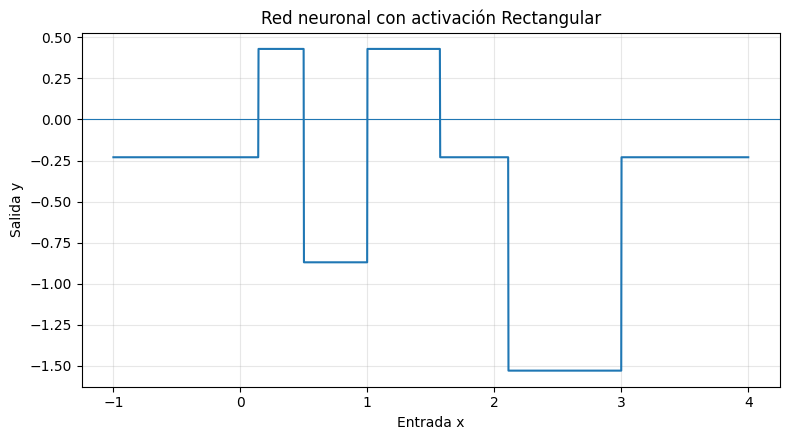

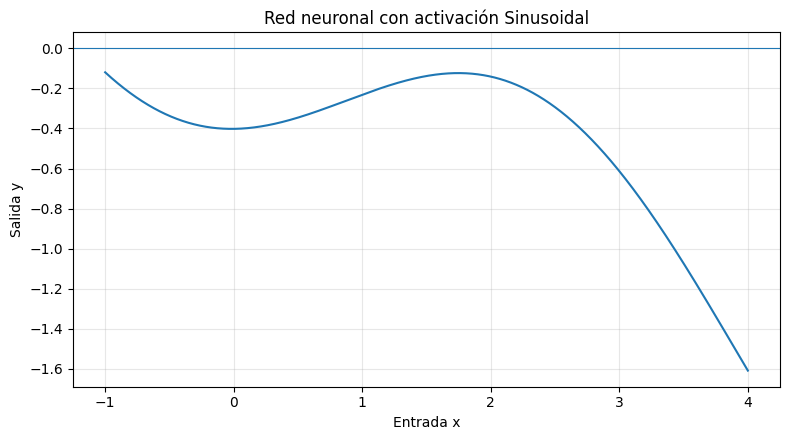

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la red
phi0 = -0.23
phi1 = -1.3
phi2 = 1.3
phi3 = 0.66

theta10 = -0.2
theta11 = 0.4

theta20 = -0.9
theta21 = 0.9

theta30 = 1.1
theta31 = -0.7


def heaviside(z):
    """Función escalón de Heaviside."""
    return np.where(z >= 0, 1.0, 0.0)


def rectangular(z):
    """Función rectangular: vale 1 cuando 0 <= z <= 1."""
    return np.where((z >= 0) & (z <= 1), 1.0, 0.0)


def salida_red(x, activacion):
    """Calcula la salida de la red para una activación dada."""
    z1 = theta10 + theta11 * x
    z2 = theta20 + theta21 * x
    z3 = theta30 + theta31 * x

    h1 = activacion(z1)
    h2 = activacion(z2)
    h3 = activacion(z3)

    return phi0 + phi1 * h1 + phi2 * h2 + phi3 * h3


# Valores de entrada
x = np.linspace(-1, 4, 2000)

# Activaciones que se van a comparar
activaciones = {
    "Heaviside": heaviside,
    "Tangente hiperbólica": np.tanh,
    "Rectangular": rectangular,
    "Sinusoidal": np.sin
}

# Una gráfica independiente para cada activación
for nombre, funcion in activaciones.items():
    y = salida_red(x, funcion)

    plt.figure(figsize=(8, 4.5))
    plt.plot(x, y)
    plt.axhline(0, linewidth=0.8)
    plt.xlabel("Entrada x")
    plt.ylabel("Salida y")
    plt.title(f"Red neuronal con activación {nombre}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#Capitulo 4
**Ejercicio 4.1**

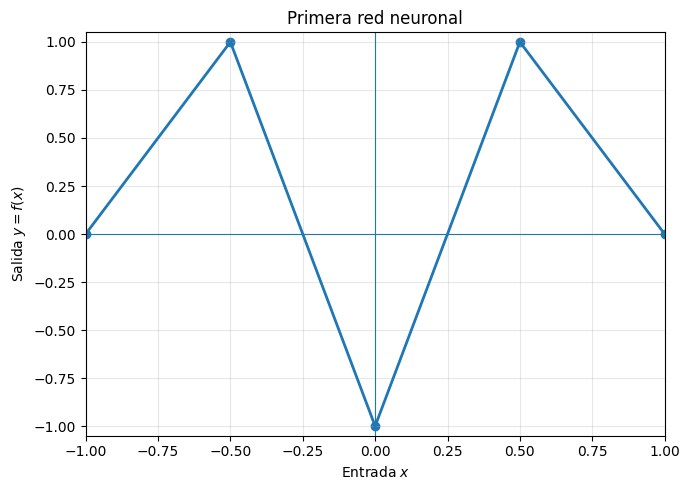

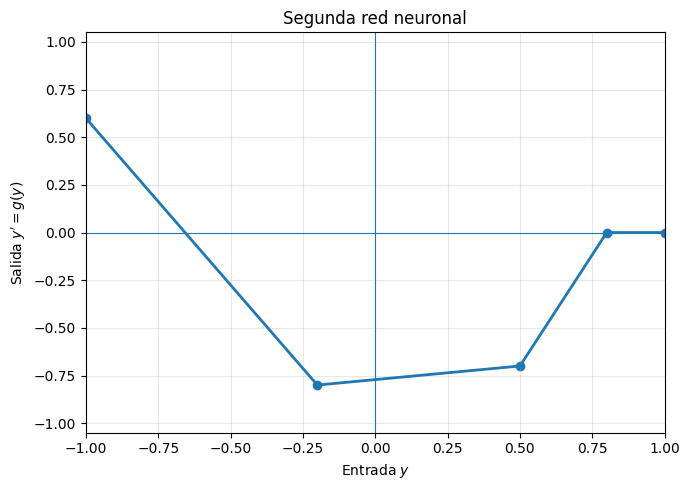

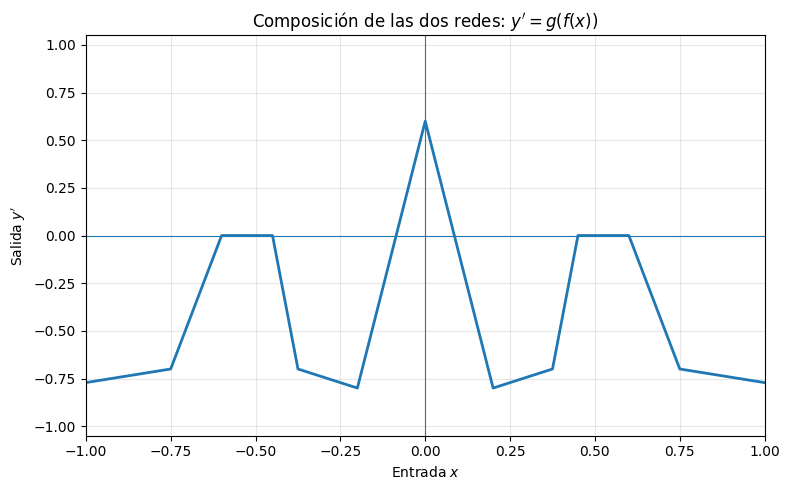

Puntos de cambio de la función compuesta:


,x,y = f(x),y' = g(f(x))
0,-1.000,0.0,-0.771429
1,-0.750,0.5,-0.700000
2,-0.600,0.8,0.000000
3,-0.500,1.0,0.000000
4,-0.450,0.8,0.000000
5,-0.375,0.5,-0.700000
6,-0.200,-0.2,-0.800000
7,0.000,-1.0,0.600000
8,0.200,-0.2,-0.800000
9,0.375,0.5,-0.700000


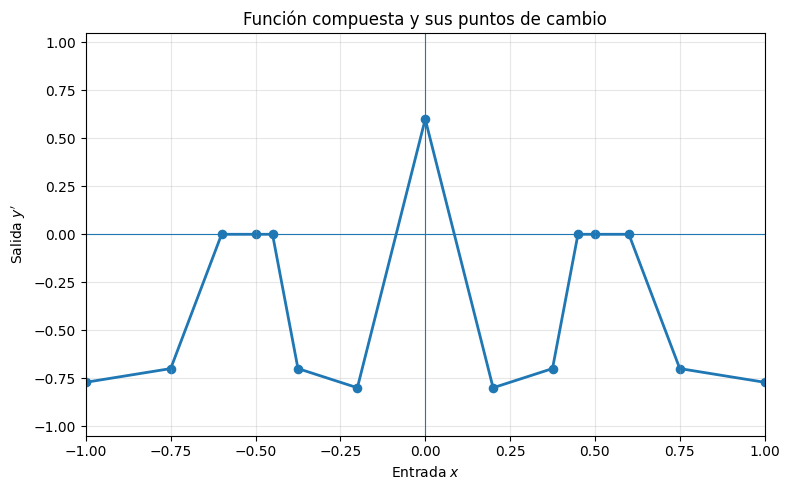

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ============================================================
# 1. Nodos de la primera red: y = f(x)
# ============================================================
#
# Los puntos que se leen en la figura son:
#
# (-1, 0), (-0.5, 1), (0, -1), (0.5, 1), (1, 0)
#

x_nodos_red1 = np.array([
    -1.0,
    -0.5,
     0.0,
     0.5,
     1.0
])

y_nodos_red1 = np.array([
     0.0,
     1.0,
    -1.0,
     1.0,
     0.0
])


# ============================================================
# 2. Nodos de la segunda red: y' = g(y)
# ============================================================
#
# Los vértices de la segunda gráfica son:
#
# (-1, 0.6), (-0.2, -0.8), (0.5, -0.7),
# (0.8, 0), (1, 0)
#

y_nodos_red2 = np.array([
    -1.0,
    -0.2,
     0.5,
     0.8,
     1.0
])

yp_nodos_red2 = np.array([
     0.6,
    -0.8,
    -0.7,
     0.0,
     0.0
])


def red_1(x: np.ndarray) -> np.ndarray:
    """
    Calcula la salida y = f(x) de la primera red.

    np.interp une los nodos mediante segmentos de recta.
    """
    return np.interp(
        x,
        x_nodos_red1,
        y_nodos_red1
    )


def red_2(y: np.ndarray) -> np.ndarray:
    """
    Calcula la salida y' = g(y) de la segunda red.
    """
    return np.interp(
        y,
        y_nodos_red2,
        yp_nodos_red2
    )


# Valores de entrada en el intervalo solicitado
x = np.linspace(-1.0, 1.0, 4001)

# Salida de la primera red
y = red_1(x)

# La salida de la primera red se convierte en la entrada
# de la segunda red
y_prima = red_2(y)


# ============================================================
# 3. Gráfica de la primera red
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(x, y, linewidth=2)
plt.scatter(x_nodos_red1, y_nodos_red1)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("Entrada $x$")
plt.ylabel("Salida $y=f(x)$")
plt.title("Primera red neuronal")
plt.xlim(-1, 1)
plt.ylim(-1.05, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 4. Gráfica de la segunda red
# ============================================================

entrada_red2 = np.linspace(-1.0, 1.0, 2001)
salida_red2 = red_2(entrada_red2)

plt.figure(figsize=(7, 5))
plt.plot(entrada_red2, salida_red2, linewidth=2)
plt.scatter(y_nodos_red2, yp_nodos_red2)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("Entrada $y$")
plt.ylabel("Salida $y'=g(y)$")
plt.title("Segunda red neuronal")
plt.xlim(-1, 1)
plt.ylim(-1.05, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 5. Gráfica de la composición y' = g(f(x))
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(x, y_prima, linewidth=2)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("Entrada $x$")
plt.ylabel("Salida $y'$")
plt.title("Composición de las dos redes: $y'=g(f(x))$")
plt.xlim(-1, 1)
plt.ylim(-1.05, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 6. Cálculo de los puntos donde cambia la pendiente
# ============================================================

# La segunda red cambia de pendiente en estos valores de y.
quiebres_red2 = y_nodos_red2[1:-1]

# Empezamos incluyendo los puntos de cambio propios de la primera red.
puntos_x = set(x_nodos_red1.tolist())

# Para cada segmento de la primera red buscamos los valores de x
# para los cuales f(x) pasa por un quiebre de la segunda red.
for i in range(len(x_nodos_red1) - 1):

    x_a = x_nodos_red1[i]
    x_b = x_nodos_red1[i + 1]

    y_a = y_nodos_red1[i]
    y_b = y_nodos_red1[i + 1]

    minimo = min(y_a, y_b)
    maximo = max(y_a, y_b)

    for quiebre in quiebres_red2:

        if minimo <= quiebre <= maximo:

            # Ecuación del segmento:
            #
            # y = y_a + (y_b-y_a)/(x_b-x_a) * (x-x_a)
            #
            # Despejamos x para y = quiebre.

            x_quiebre = (
                x_a
                + (quiebre - y_a)
                * (x_b - x_a)
                / (y_b - y_a)
            )

            puntos_x.add(round(float(x_quiebre), 12))


# Ordenamos los puntos
puntos_x = np.array(sorted(puntos_x))

# Calculamos la salida de las dos redes en estos puntos
puntos_y = red_1(puntos_x)
puntos_y_prima = red_2(puntos_y)

tabla = pd.DataFrame({
    "x": puntos_x,
    "y = f(x)": puntos_y,
    "y' = g(f(x))": puntos_y_prima
})

print("Puntos de cambio de la función compuesta:")
display(tabla.round(6))


# ============================================================
# 7. Gráfica final con los puntos de cambio
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(x, y_prima, linewidth=2)
plt.scatter(puntos_x, puntos_y_prima, s=35)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("Entrada $x$")
plt.ylabel("Salida $y'$")
plt.title("Función compuesta y sus puntos de cambio")
plt.xlim(-1, 1)
plt.ylim(-1.05, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Ejericio 4.8**

Parámetros obtenidos:
phi0 = 4.000000
phi1 = -12.000000
phi2 = 9.000000
phi3 = -6.000000

Verificación de la función:
x = 0.000000, f(x) = 0.000000
x = 0.166667, f(x) = 1.000000
x = 0.333333, f(x) = 0.000000
x = 0.666667, f(x) = 1.000000
x = 1.000000, f(x) = -0.000000


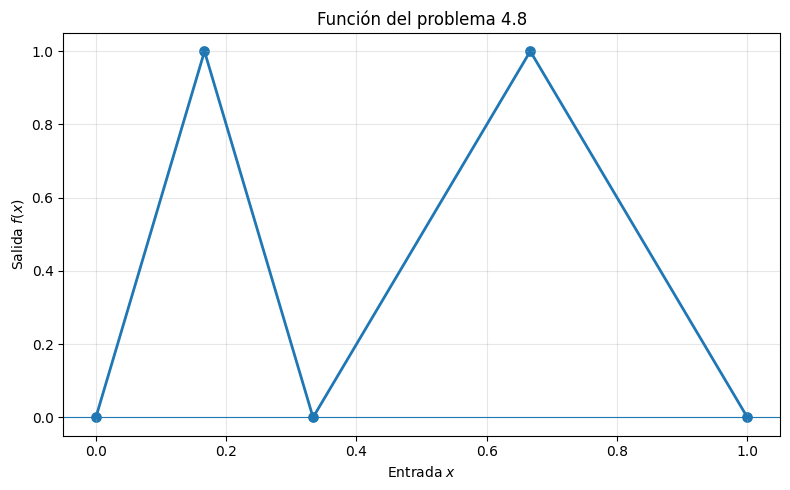

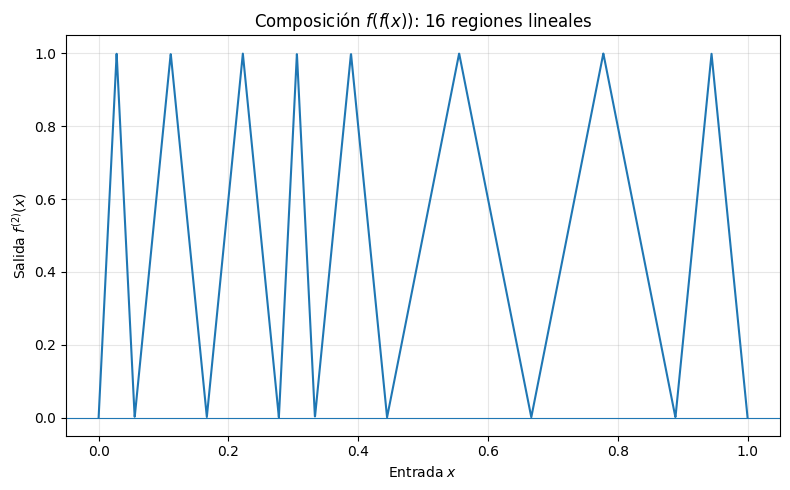

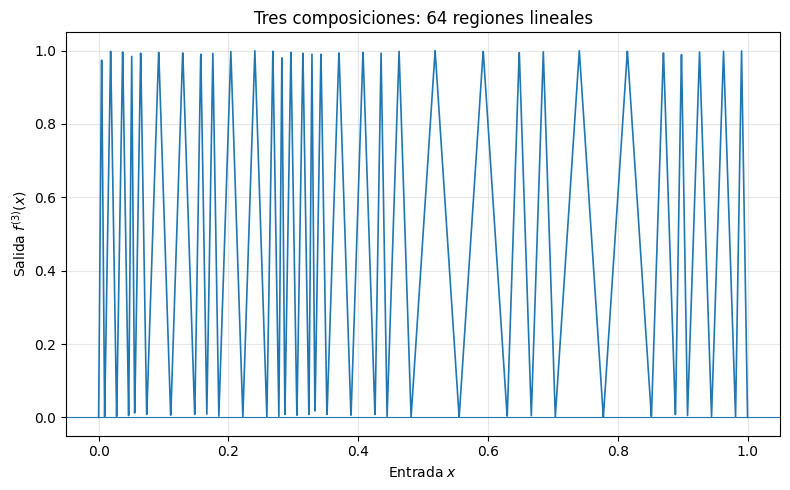


Número teórico de regiones:
K = 1: 4 regiones
K = 2: 16 regiones
K = 3: 64 regiones
K = 4: 256 regiones
K = 5: 1,024 regiones
K = 6: 4,096 regiones


In [5]:
import numpy as np
import matplotlib.pyplot as plt


def relu(z):
    """Función de activación ReLU."""
    return np.maximum(0.0, z)


def unidades_ocultas(x):
    """
    Calcula las tres activaciones de la figura 4.9.
    """
    h1 = relu(x - 1.0 / 6.0)
    h2 = relu(x - 2.0 / 6.0)
    h3 = relu(4.0 / 6.0 - x)

    return h1, h2, h3


# ============================================================
# 1. Cálculo de los parámetros phi
# ============================================================
#
# Se imponen las condiciones:
#
# f(0)   = 0
# f(1/6) = 1
# f(2/6) = 0
# f(4/6) = 1
#
# Como:
#
# f(x) = phi0 + phi1*h1(x) + phi2*h2(x) + phi3*h3(x),
#
# estas condiciones forman un sistema lineal de cuatro
# ecuaciones con cuatro incógnitas.
# ============================================================

puntos_x = np.array([
    0.0,
    1.0 / 6.0,
    2.0 / 6.0,
    4.0 / 6.0
])

valores_deseados = np.array([
    0.0,
    1.0,
    0.0,
    1.0
])

matriz_sistema = []

for x_i in puntos_x:
    h1_i, h2_i, h3_i = unidades_ocultas(x_i)

    matriz_sistema.append([
        1.0,
        h1_i,
        h2_i,
        h3_i
    ])

matriz_sistema = np.array(matriz_sistema)

phi = np.linalg.solve(
    matriz_sistema,
    valores_deseados
)

phi0, phi1, phi2, phi3 = phi

print("Parámetros obtenidos:")
print(f"phi0 = {phi0:.6f}")
print(f"phi1 = {phi1:.6f}")
print(f"phi2 = {phi2:.6f}")
print(f"phi3 = {phi3:.6f}")


# ============================================================
# 2. Definición de la red
# ============================================================

def red(x):
    """
    Evalúa la función construida con los parámetros calculados.
    """
    h1, h2, h3 = unidades_ocultas(x)

    return (
        phi0
        + phi1 * h1
        + phi2 * h2
        + phi3 * h3
    )


# Verificación en los puntos importantes
puntos_verificacion = np.array([
    0.0,
    1.0 / 6.0,
    2.0 / 6.0,
    4.0 / 6.0,
    1.0
])

print("\nVerificación de la función:")

for x_i in puntos_verificacion:
    print(
        f"x = {x_i:.6f}, "
        f"f(x) = {red(x_i):.6f}"
    )


# ============================================================
# 3. Gráfica de la función original
# ============================================================

x = np.linspace(0.0, 1.0, 4001)
y = red(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=2)
plt.scatter(
    puntos_verificacion,
    red(puntos_verificacion),
    s=45
)
plt.axhline(0.0, linewidth=0.8)
plt.xlabel("Entrada $x$")
plt.ylabel("Salida $f(x)$")
plt.title("Función del problema 4.8")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 4. Composición de la red
# ============================================================

def composicion(x, numero_composiciones):
    """
    Calcula f compuesta consigo misma el número indicado de veces.

    numero_composiciones = 1 produce f(x)
    numero_composiciones = 2 produce f(f(x))
    numero_composiciones = 3 produce f(f(f(x)))
    """
    resultado = np.asarray(x, dtype=float)

    for _ in range(numero_composiciones):
        resultado = red(resultado)

    return resultado


# Composición de la función consigo misma dos veces
y_composicion_2 = composicion(x, 2)

plt.figure(figsize=(8, 5))
plt.plot(x, y_composicion_2, linewidth=1.5)
plt.axhline(0.0, linewidth=0.8)
plt.xlabel("Entrada $x$")
plt.ylabel("Salida $f^{(2)}(x)$")
plt.title("Composición $f(f(x))$: 16 regiones lineales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Composición de la función consigo misma tres veces
y_composicion_3 = composicion(x, 3)

plt.figure(figsize=(8, 5))
plt.plot(x, y_composicion_3, linewidth=1.2)
plt.axhline(0.0, linewidth=0.8)
plt.xlabel("Entrada $x$")
plt.ylabel("Salida $f^{(3)}(x)$")
plt.title("Tres composiciones: 64 regiones lineales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 5. Número de regiones para distintos valores de K
# ============================================================

print("\nNúmero teórico de regiones:")

for K in range(1, 7):
    numero_regiones = 4 ** K

    print(
        f"K = {K}: "
        f"{numero_regiones:,} regiones"
    )

##

#Capitulo 5
**Ejercicio 5.2**

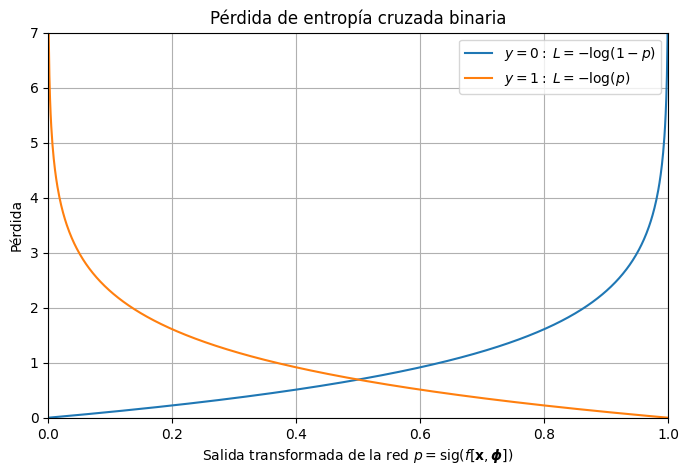

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Evitamos usar exactamente 0 y 1 porque log(0) no está definido.
epsilon = 1e-6

# Valores posibles de la salida transformada de la red.
p = np.linspace(epsilon, 1 - epsilon, 1000)

# Pérdida cuando la etiqueta real es y = 0.
loss_y0 = -np.log(1 - p)

# Pérdida cuando la etiqueta real es y = 1.
loss_y1 = -np.log(p)

plt.figure(figsize=(8, 5))

plt.plot(
    p,
    loss_y0,
    label=r"$y=0:\;L=-\log(1-p)$"
)

plt.plot(
    p,
    loss_y1,
    label=r"$y=1:\;L=-\log(p)$"
)

plt.xlabel(
    r"Salida transformada de la red "
    r"$p=\operatorname{sig}(f[\mathbf{x},\boldsymbol{\phi}])$"
)
plt.ylabel("Pérdida")
plt.title("Pérdida de entropía cruzada binaria")
plt.xlim(0, 1)
plt.ylim(0, 7)
plt.grid(True)
plt.legend()
plt.show()